(fin-edu:investing:merton:colab)=
# Merton's portfolio problem - Example

Merton's portfolio problem aims at finding the optimal value of the fraction the risky asset $\pi_t$, in a 2-asset portfolio: the risky asset and a risk-free asset. The optimal solution is the fraction $\pi^*_t$ that maximizes the value function

$$V(x,t) = \mathbb{E} \left[ \left. \int_{s=t}^{T} e^{- \rho (s-t)} u(c_s) \, ds + e^{-\rho(T-t)} B(T) u(X_T) \right| X_t = x \right] \ ,$$

i.e. a discounted return of a utility function $u(c_s)$, depending on the consumption $c_s$ at time $s \in [t, T]$ with a weight of utility function evaluated for the final value of the wealth $X_T$, modeling the bequest, weighted with $B(T)$, and subject to the dynamics of wealth $X_t$ goverend by the SDE

$$\begin{aligned}
  dX_t & = \underbrace{\left[ r_t + \left( \mu_t - r_t \right) \pi_t \right] X_t \, dt}_{\text{expected return}} - \underbrace{c_t \, dt}_{\text{consumption}} + \underbrace{\pi_t \sigma_t X_t \, dW_t}_{\text{volatility of the return}} \ .
\end{aligned}$$



Under the assumption of CCRA, i.e. with the expression of the utility function

$$u(x) = \frac{x^{1-\gamma}}{1 - \gamma} \ ,$$

being $\gamma$ the **personal risk-adversion factor**, the optimal solution provides:
* a value of optimal fraction invested in the risky asset $\pi^*$ **constant in time** (did you say [rebalancing](fin-edu:rebalancing-intro)?),

   $$\pi^*_t = \frac{\mu - r}{\gamma \sigma^2} \ ,$$

   with $\mu$, $\sigma^2$ the expected value and the variance of the return of the risky asset, and $r$ the risk-free return

* the expression of the consumption $c_t$, that's proportional to the wealth $X_t$,

   $$c_t  = \frac{X_t}{f(t)} \ ,$$

   through a function of time $f(t)$.



Function $f(t)$ is

$$f(t) =
\begin{cases}
  \dfrac{1}{\nu} + \left( \varepsilon - \dfrac{1}{\nu} \right) e^{-\nu (T-t)} & \text{,} \quad \text{ if $\nu \ne 0$} \\
  T - t + \varepsilon                                                         & \text{,} \quad \text{ if $\nu =   0$} \\
\end{cases}$$

with

$$\nu = \dfrac{1}{\gamma} \left\{ \rho - (1 - \gamma) \left( \dfrac{(\mu-r)^2}{2 \sigma^2 \gamma} + r  \right)  \right\} \ .$$




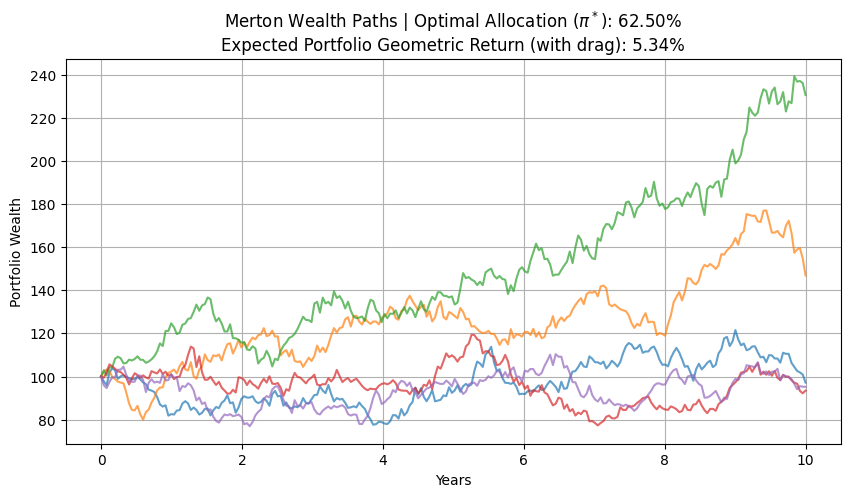

interactive(children=(FloatSlider(value=2.0, description='Gamma (Risk)', max=5.0, min=0.5), FloatSlider(value=…

<function __main__.simulate_merton(gamma, rho, sigma, T=10, N=252, paths=5)>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

def simulate_merton(gamma, rho, sigma, T=10, N=252, paths=5):
    # Fixed Market Parameters
    r = 0.03
    mu = 0.08
    X0 = 100
    dt = T / N
    t = np.linspace(0, T, N)
    
    # 1. Calculate Merton Optimal Decisions
    # Guard against division by zero
    pi_star = (mu - r) / (gamma * (sigma ** 2))
    
    # Value function parameter nu from your formula
    nu = (1/gamma) * (rho - (1 - gamma) * (((mu - r)**2) / (2 * sigma**2 * gamma) + r))
    
    # Assuming infinite horizon or terminal bequest boundary epsilon=1 for f(t) simplicity here
    # For a simple simulation baseline, we use the constant asymptotic consumption rate psi* = nu
    psi_star = max(0.001, nu) 
    
    # 2. Simulate Paths
    plt.figure(figsize=(10, 5))
    
    for _ in range(paths):
        X = np.zeros(N)
        X[0] = X0
        for s in range(1, N):
            # Stochastic step (Wiener process)
            dW = np.random.normal(0, np.sqrt(dt))
            
            # Wealth SDE: dXt = [r + (mu - r)*pi]*Xt*dt - ct*dt + pi*sigma*Xt*dW
            # Where ct = psi_star * Xt
            expected_growth = (r + (mu - r) * pi_star - psi_star) * X[s-1] * dt
            volatility_term = pi_star * sigma * X[s-1] * dW
            
            X[s] = X[s-1] + expected_growth + volatility_term
            if X[s] <= 0:  # Ruin condition
                X[s:] = 0
                break
                
        plt.plot(t, X, alpha=0.7)
        
    # Expected drag-adjusted geometric return rate
    geom_return = (r + (mu - r)*pi_star) - 0.5*(pi_star**2)*(sigma**2)
    
    plt.title(f"Merton Wealth Paths | Optimal Allocation ($\pi^*$): {pi_star:.2%}\n"
              f"Expected Portfolio Geometric Return (with drag): {geom_return:.2%}")
    plt.xlabel("Years")
    plt.ylabel("Portfolio Wealth")
    plt.grid(True)
    plt.show()

# Create interactive sliders directly in Jupyter
interact(simulate_merton, 
         gamma=FloatSlider(min=0.5, max=5.0, step=0.1, value=2.0, description='Gamma (Risk)'),
         rho=FloatSlider(min=0.01, max=0.10, step=0.005, value=0.04, description='Rho (Discount)'),
         sigma=FloatSlider(min=0.10, max=0.40, step=0.01, value=0.20, description='Sigma (Vol)'))